In [5]:
# Imports
import torch
import timm
from functools import partial
import dinov2.models.vision_transformer as vits
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn.functional as F
import types
from torchvision import transforms
import dinov2.layers as layers #noqa
import inspect # noqa

from dino_visualizer import visualize_attention_maps

In [6]:
model_path = 'models/dinov2_vits14_reg4_pretrain.pth'
state_dict = torch.load(model_path, map_location='cpu')
print(type(state_dict))

<class 'dict'>


In [9]:
print(timm.list_models('*dinov2*'))
# Not using timm since there is a slight name mismatch between state dict (reg_token vs register_token)

['vit_base_patch14_dinov2', 'vit_base_patch14_reg4_dinov2', 'vit_giant_patch14_dinov2', 'vit_giant_patch14_reg4_dinov2', 'vit_large_patch14_dinov2', 'vit_large_patch14_reg4_dinov2', 'vit_small_patch14_dinov2', 'vit_small_patch14_reg4_dinov2']


In [10]:
model = vits.vit_small(img_size=518, patch_size=14, num_register_tokens=4, init_values=1.0, block_chunks=0)

ckpt = torch.load('models/dinov2_vits14_reg4_pretrain.pth', map_location='cpu')
model.load_state_dict(ckpt)

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
model = model.to(device).eval()
print("Ready on", device)

Ready on mps


### Few things to note
- xFormers is a library to make CUDA related operations more efficient and performant. Since I'm working on a Mac, this is not something I can use. (-fopenmp is something that is used by a parallelizer to create multithread useable code that works perfectly on cuda GPUs. Workaround being just not installing this (not like it will install anyway))

- The numbers in the transforms.Normalize: 
    ```
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    ```

    These numbers are the mean pixel values for the R, G and B channels respectively, and standard deviation. It basically keeps the mean pixel values centered around 0 instead of whatever the actual mean is.
    Those values are obtained, and verified by running the statistical observation tests across all the images in the **ImageNet** dataset, hence the specificity. Others might just use [0.5, 0.5. 0.5] for their mean and it might just work out fine.

In [11]:


transform = transforms.Compose([
    transforms.Resize((518, 518)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

img = Image.open('climb holds good.v2i.sam2/train/0ea408b3-a616-4f05-868e-e8b494619a71_jpg.rf.8c6f407b890281b58e6bd270db7c2912.jpg').convert('RGB')
x = transform(img).unsqueeze(0).to(device)  # (1, 3, 518, 518)

attn_output = {}

def hook_fn(module, input, output):
    attn_output['attn'] = output  # shape: (B, num_heads, N, N)

# blocks[-1] is the last transformer block, .attn is the attention module
hook = model.blocks[-1].attn.register_forward_hook(hook_fn) # Calls the function in question every single time a forward() pass happens

with torch.no_grad():
    out = model.forward_features(x)

hook.remove()  # always clean up

attn = attn_output['attn']  # (1, 6, 1374, 1374)
# dim 2/3 = num_tokens = 1 CLS + 4 reg + 1369 patches

Note: the hook above was an attempt to retrieve the attention map non-invasively — without modifying any model code — by capturing the attention module's output. This was insufficient because the underlying op (scaled_dot_product_attention / memory_efficient_attention) computes the softmax-weighted attention internally using a fused kernel, and never materializes the intermediate (N, N) attention matrix as a tensor. Only the final collapsed output (B, N, C) is returned, which is all the hook can see. Hence the monkey-patch — replacing forward with an explicit, unfused implementation that exposes attn_weights before it gets collapsed.

### Bit more context before moving to the attention maps:
- The CLS Map, which gives the attention of the entire image, is a representation of how the CLS token attends to the patches of the image. What does the CLS token do? It helps create a global image summary, so the different things it 'attends' to, are things that are essential in giving the overall image its context/meaning.
- This is a SINGLE ROW IN THE FINAL OUTPUT THAT WE GET, of dimension (_, _, 1, 1374)

In [12]:
print(attn.shape)



torch.Size([1, 1374, 384])


- **Emphasis on the fact that, the defaullt size and shape that the memory efficient attention, and scaled dot product attention is the above (1, 1374, 384), also written as (1, num_tokens, embedding_dimension)**

In [13]:
print(inspect.getsource(layers.MemEffAttention))

class MemEffAttention(Attention):
    def forward(self, x: Tensor, attn_bias=None) -> Tensor:
        if not XFORMERS_AVAILABLE:
            if attn_bias is not None:
                raise AssertionError("xFormers is required for using nested tensors")
            return super().forward(x)

        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads)

        q, k, v = unbind(qkv, 2)

        x = memory_efficient_attention(q, k, v, attn_bias=attn_bias)
        x = x.reshape([B, N, C])

        x = self.proj(x)
        x = self.proj_drop(x)
        return x



- So if xformers is unavailable (like in my case) the code defaults to the forward pass in the parent 'Attention' class.

In [7]:
attn_layer_module = layers.attention
print(attn_layer_module.XFORMERS_ENABLED)

attn_layer_module.XFORMERS_ENABLED = False

from dinov2.layers import Attention #noqa
print(inspect.getsource(Attention))

True
class Attention(nn.Module):
    def __init__(
        self,
        dim: int,
        num_heads: int = 8,
        qkv_bias: bool = False,
        proj_bias: bool = True,
        attn_drop: float = 0.0,
        proj_drop: float = 0.0,
    ) -> None:
        super().__init__()
        self.dim = dim
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim**-0.5

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = attn_drop
        self.proj = nn.Linear(dim, dim, bias=proj_bias)
        self.proj_drop = nn.Dropout(proj_drop)

    def init_weights(
        self, init_attn_std: float | None = None, init_proj_std: float | None = None, factor: float = 1.0
    ) -> None:
        init_attn_std = init_attn_std or (self.dim**-0.5)
        init_proj_std = init_proj_std or init_attn_std * factor
        nn.init.normal_(self.qkv.weight, std=init_attn_std)
        nn.init.normal_(self.proj.weight, std=init_proj_std)
     

Here, the 'Attention' class uses `nn.functional.scaled_dot_product_attention`. Which, when I try to visualize:

I try: 
```print(inspect.getsource(torch.nn.functional.scaled_dot_product_attention))```


Which would work if it was a python function, but it's implemented in either CPP or CUDA which cant be visualized here as a function.


In [8]:
def attention_forward_with_maps(self, x, is_causal=False):
    B, N, C = x.shape
    qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads)
    q, k, v = torch.unbind(qkv, 2)
    q, k, v = [t.transpose(1, 2) for t in [q, k, v]]

    # So essentially this code for the rest of this function, is like a python replication of the actual attention black box code (for a python dev like me) that is fused inside a CUDA kernel.
    scale = (C // self.num_heads) ** -0.5
    scores = (q @ k.transpose(-2, -1)) * scale
    attn_weights = scores.softmax(dim=-1)

    self._attn_weights = attn_weights  # stash for later

    out = attn_weights @ v
    out = out.transpose(1, 2).contiguous().view(B, N, C)
    out = self.proj_drop(self.proj(out))
    return out

# The is_causal flag is more of a general attention flag, which determines if the function is allowed to see only past (autoregressive, flag set to True) or all the available tokens (flag set to False).
# In this case, there is no past or future tokens, there are patches, and all are available to see at the same time, so the flag is unused, and remains False.

### What is the distinction between `forward` and `forward_features`?
- The `forward` method is a smol wrapper around `forward_features`. What is does, is that, if the model is being trained (is_training is True) then it functions identically to `forward_features`.
- Otherwise, it only gives us the CLS_TOKEN, and discards the rest.
- Forward features is the one that gives everything as output - the cls, register, patch tokens and the masks - hence using it for all our calls everywhere.


In [9]:
print(inspect.getsource(model.forward))

    def forward(self, *args, is_training=False, **kwargs):
        ret = self.forward_features(*args, **kwargs)
        if is_training:
            return ret
        else:
            return self.head(ret["x_norm_clstoken"])



In [10]:
print(inspect.getsource(model.forward_features))

    def forward_features(self, x, masks=None):
        if isinstance(x, list):
            return self.forward_features_list(x, masks)

        x = self.prepare_tokens_with_masks(x, masks)

        for blk in self.blocks:
            x = blk(x)

        x_norm = self.norm(x)
        return {
            "x_norm_clstoken": x_norm[:, 0],
            "x_norm_regtokens": x_norm[:, 1 : self.num_register_tokens + 1],
            "x_norm_patchtokens": x_norm[:, self.num_register_tokens + 1 :],
            "x_prenorm": x,
            "masks": masks,
        }



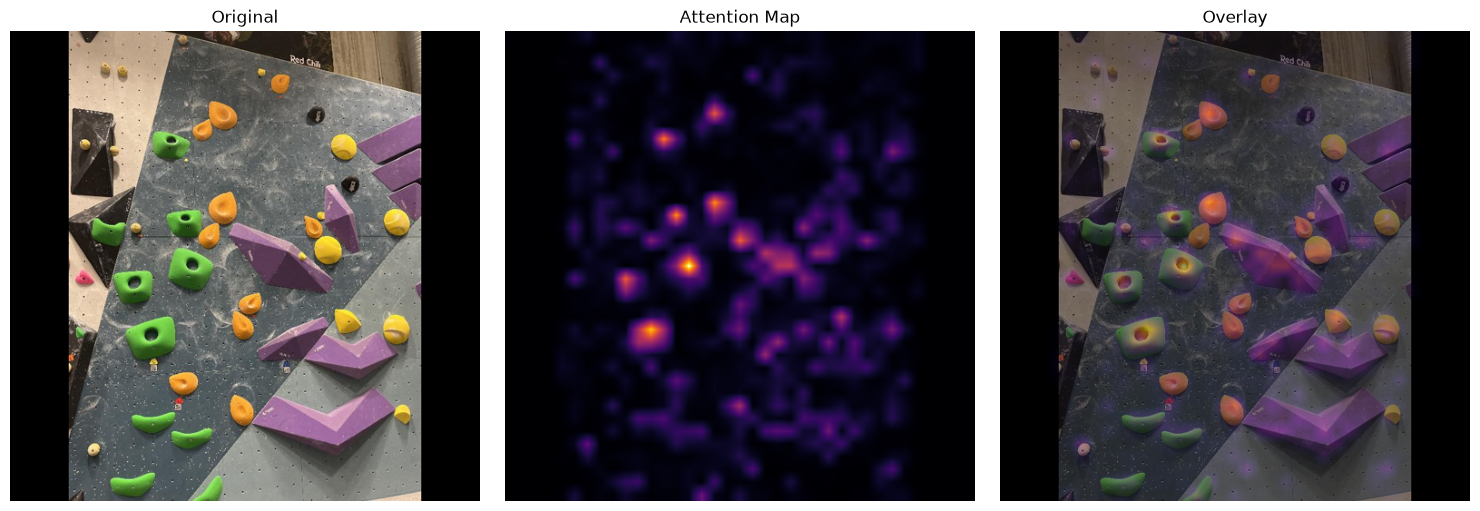

In [11]:
last_attn = model.blocks[-1].attn
last_attn.forward = types.MethodType(attention_forward_with_maps, last_attn)

# No grad here basically says 'dont bother making a computation graph, I'm not gonna do any backprop anyway'
with torch.no_grad():
    out = model.forward_features(x)  # x is your preprocessed (1, 3, 518, 518) tensor

attn = last_attn._attn_weights  # (1, 6, 1374, 1374) — NOW it exists

# --- 3. get CLS->patch attention ---
cls_attn = attn[0, :, 0, 5:]          # (6, 1369)
cls_attn_mean = cls_attn.mean(0)       # (1369,)

# --- 4. reshape to spatial grid and upsample to image size ---
grid_size = 518 // 14  # 37
attn_map = cls_attn_mean.reshape(1, 1, grid_size, grid_size)
attn_map = F.interpolate(attn_map, size=(518, 518), mode='bilinear', align_corners=False)
attn_map = attn_map.squeeze().cpu().numpy()  # (518, 518)

# --- 5. normalize to [0, 1] for colormap ---
attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min())

# --- 6. overlay ---
original = img.resize((518, 518))  # PIL image, already loaded earlier

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(original)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(attn_map, cmap='inferno')
axes[1].set_title('Attention Map')
axes[1].axis('off')

axes[2].imshow(original)
axes[2].imshow(attn_map, cmap='inferno', alpha=0.5)
axes[2].set_title('Overlay')
axes[2].axis('off')

plt.tight_layout()
# plt.savefig('attention_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

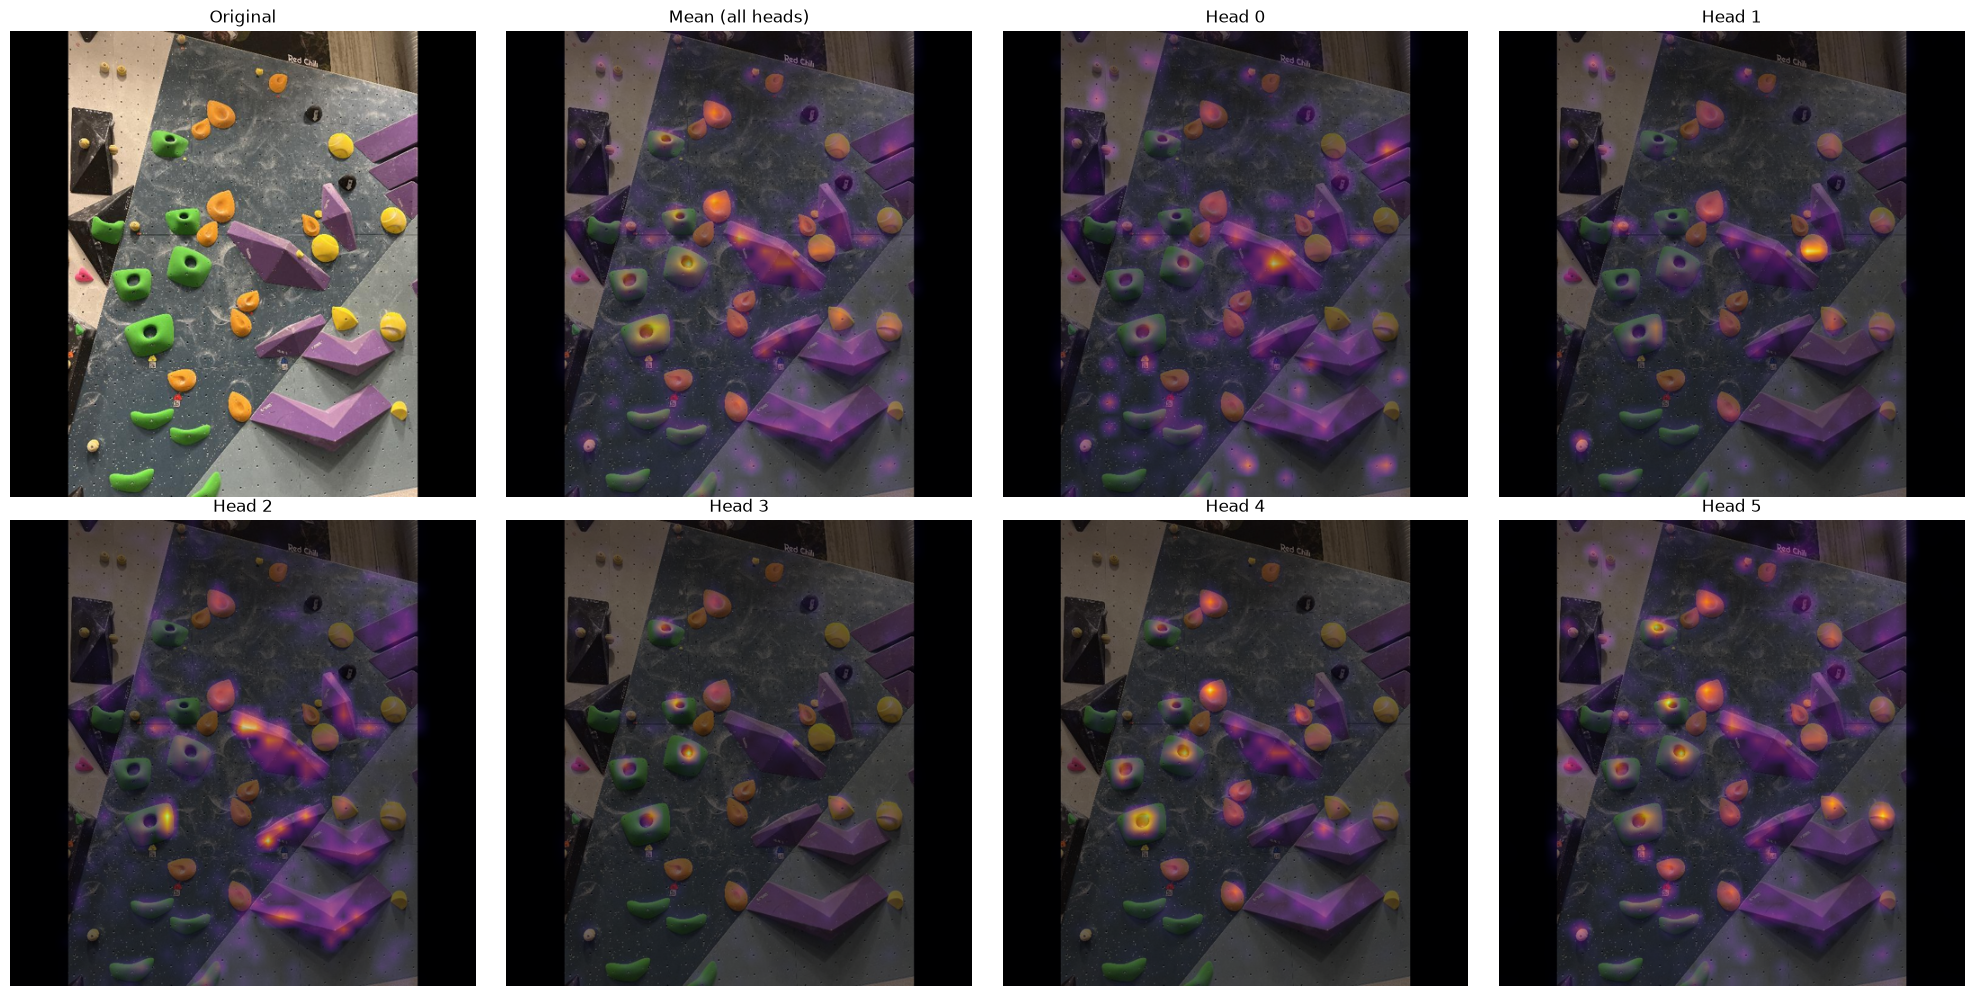

In [12]:
cls_attn = attn[0, :, 0, 5:]   # (6, 1369) — don't mean yet

grid_size = 518 // 14  # 37
cls_attn_grid = cls_attn.reshape(6, 1, grid_size, grid_size)  # (6, 1, 37, 37)

attn_maps_up = F.interpolate(cls_attn_grid, size=(518, 518), mode='bilinear', align_corners=False)
attn_maps_up = attn_maps_up.squeeze(1).cpu().numpy()  # (6, 518, 518)

# normalize each head independently (so they're comparable in their own range)
for i in range(6):
    a = attn_maps_up[i]
    attn_maps_up[i] = (a - a.min()) / (a.max() - a.min())

original = img.resize((518, 518))

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

axes[0, 0].imshow(original)
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

# put mean in the second slot for comparison
mean_map = attn_maps_up.mean(0)
axes[0, 1].imshow(original)
axes[0, 1].imshow(mean_map, cmap='inferno', alpha=0.5)
axes[0, 1].set_title('Mean (all heads)')
axes[0, 1].axis('off')

for i in range(6):
    row, col = divmod(i + 2, 4)
    axes[row, col].imshow(original)
    axes[row, col].imshow(attn_maps_up[i], cmap='inferno', alpha=0.6)
    axes[row, col].set_title(f'Head {i}')
    axes[row, col].axis('off')

plt.tight_layout()
# plt.savefig('attention_heads_individual.png', dpi=150, bbox_inches='tight')
plt.show()

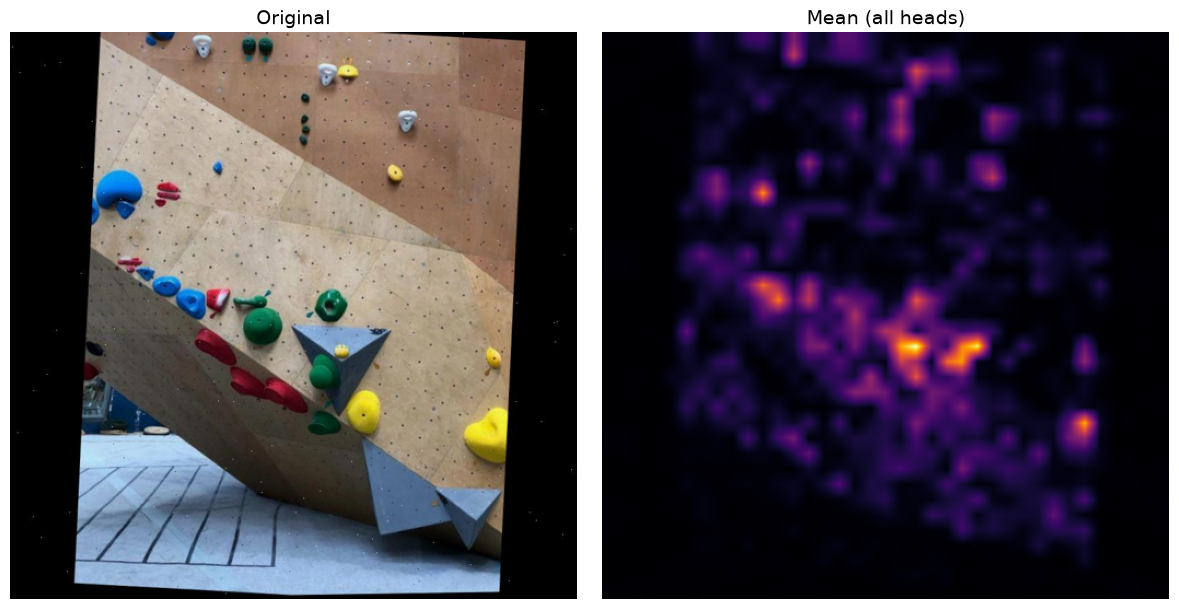

In [18]:
# Signature: def visualize_attention_maps(ckpt_path, image_path, num_registers=4, view_mode="superimposed", mean=True, output_path='results/attention_map_with_registers'):
'''
This is the view with the model that uses register tokens
'''

visualize_attention_maps(
    'models/dinov2_vits14_reg4_pretrain.pth', 
    "climb holds good.v2i.sam2/train/2dsEiLjzMJpbtfyPj_jpg.rf.3b9e2bd5636268b9985b772a1e7f3a78.jpg", 
    num_registers=4, 
    view_mode="isolated", 
    mean=True
)


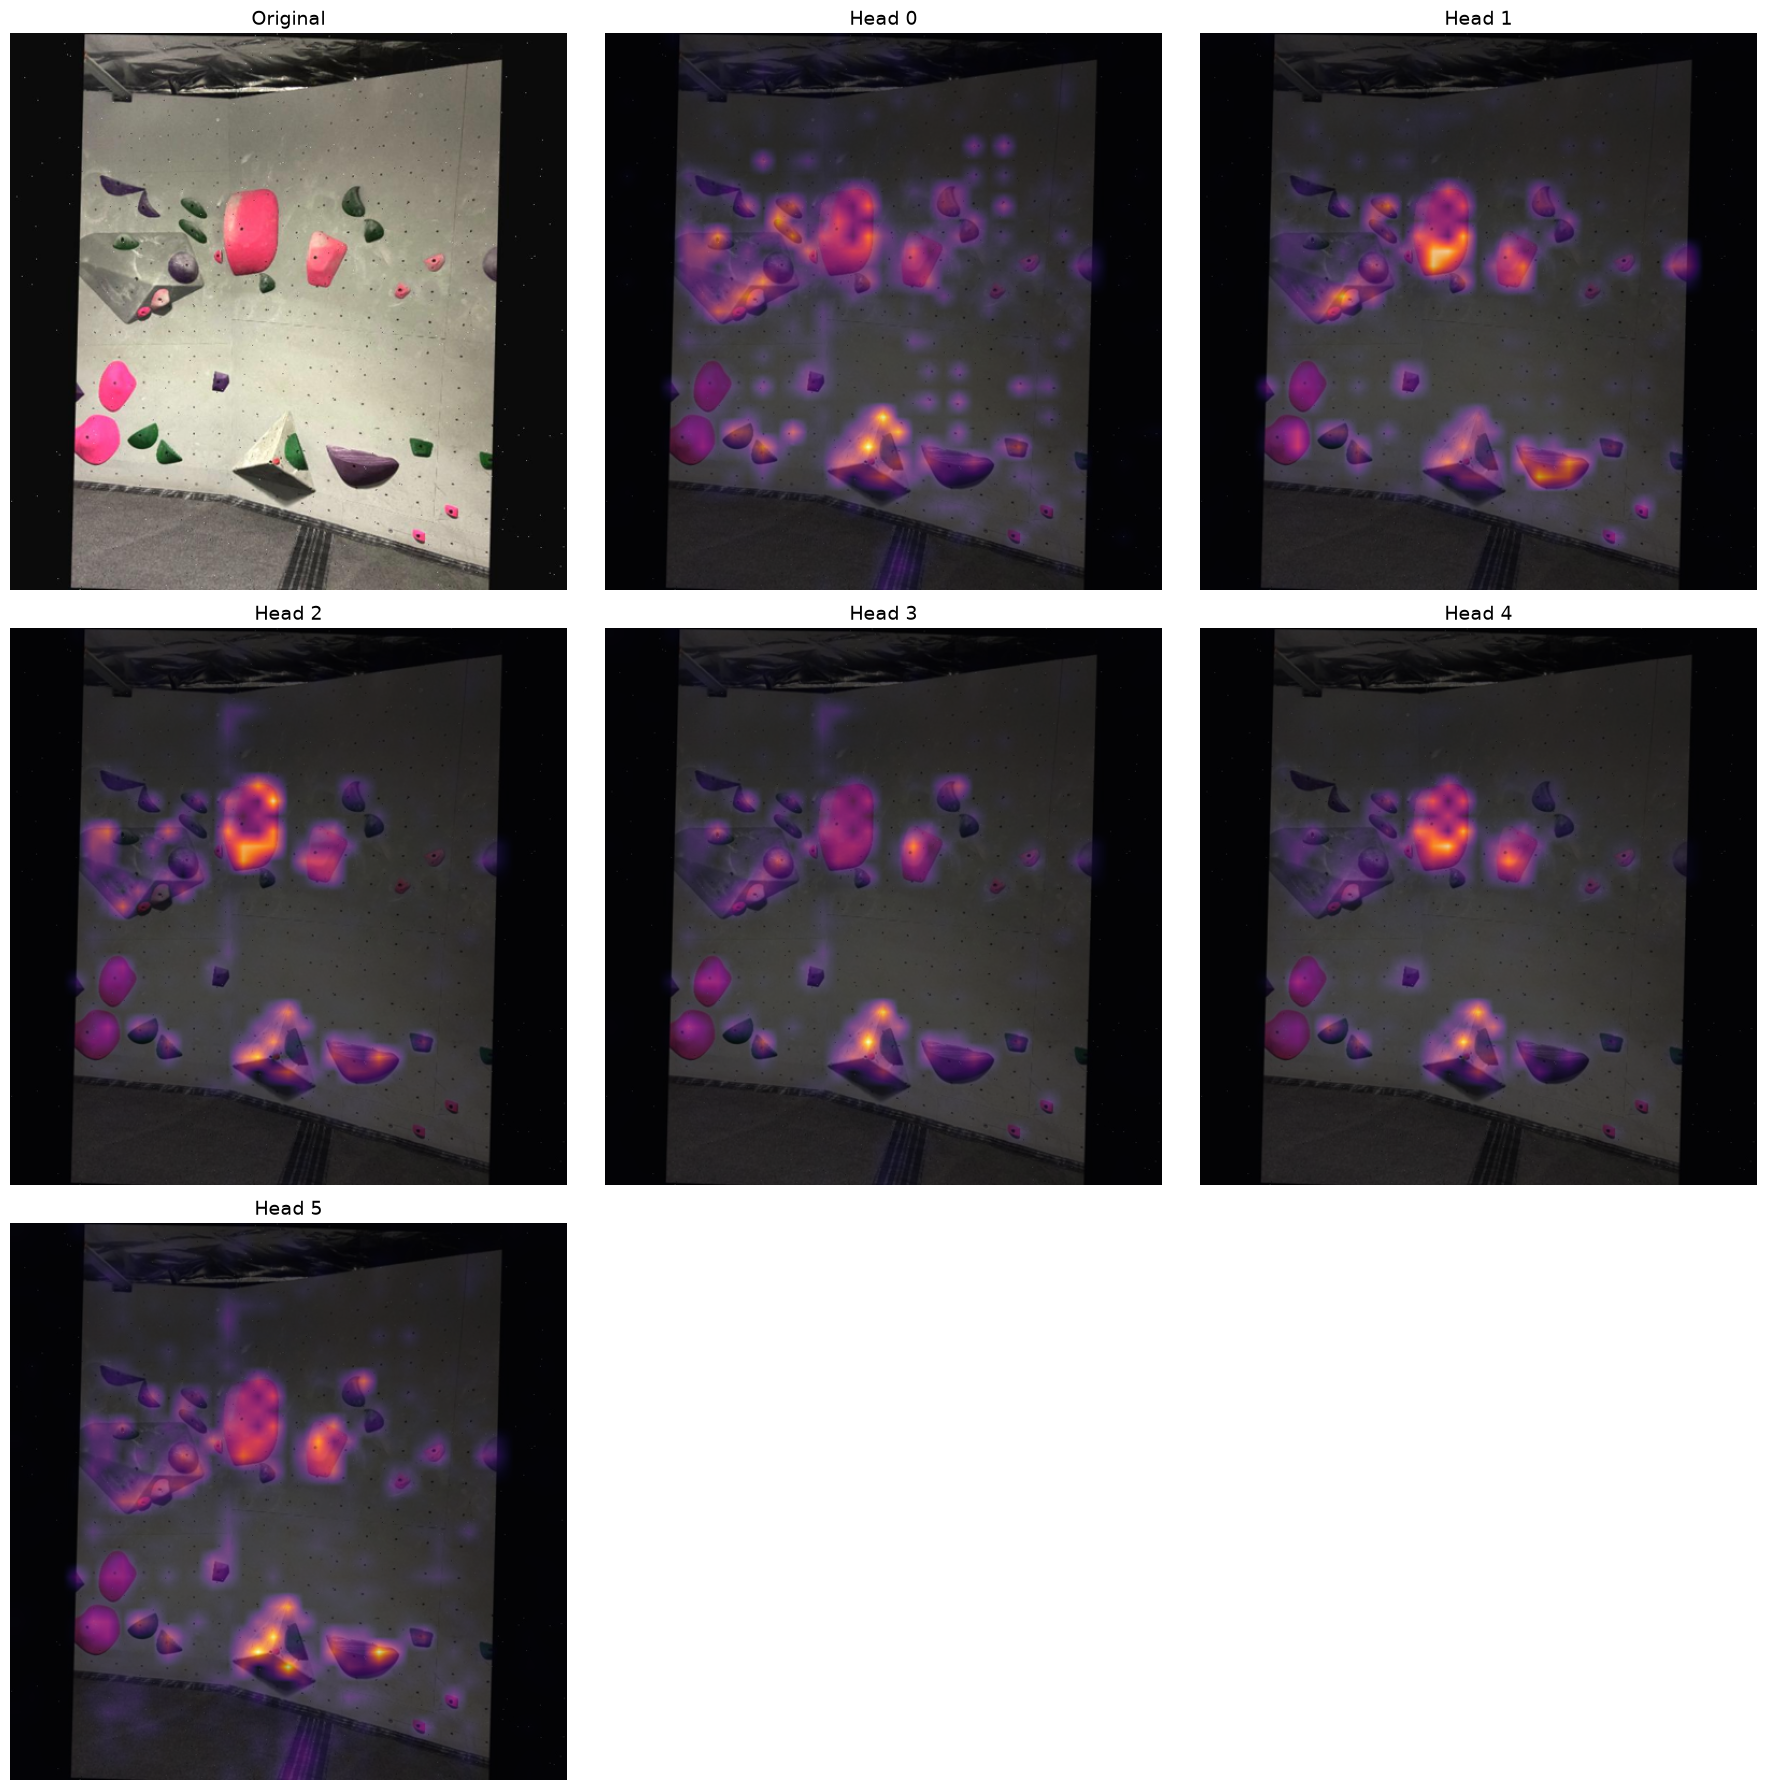

In [15]:
visualize_attention_maps(
    'models/dinov2_vits14_reg4_pretrain.pth', 
    "climb holds good.v2i.sam2/train/wall_img_9_jpg.rf.6d8b7d9635c900264cde6ac6968d2c43.jpg", 
    num_registers=4, 
    view_mode="superimposed", 
    mean=False
)


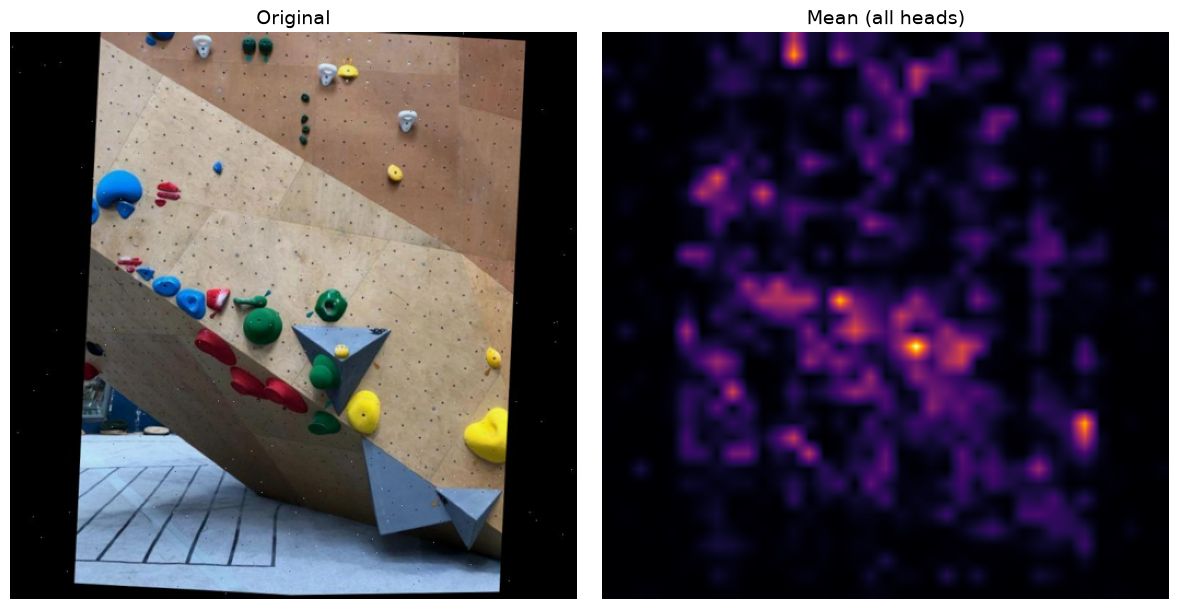

In [21]:
visualize_attention_maps(
    'models/dinov2_vits14_pretrain.pth', 
    "climb holds good.v2i.sam2/train/2dsEiLjzMJpbtfyPj_jpg.rf.3b9e2bd5636268b9985b772a1e7f3a78.jpg", 
    num_registers=0, 
    view_mode="isolated", 
    mean=True,
    output_path='results/attention_map_without_registers'
)

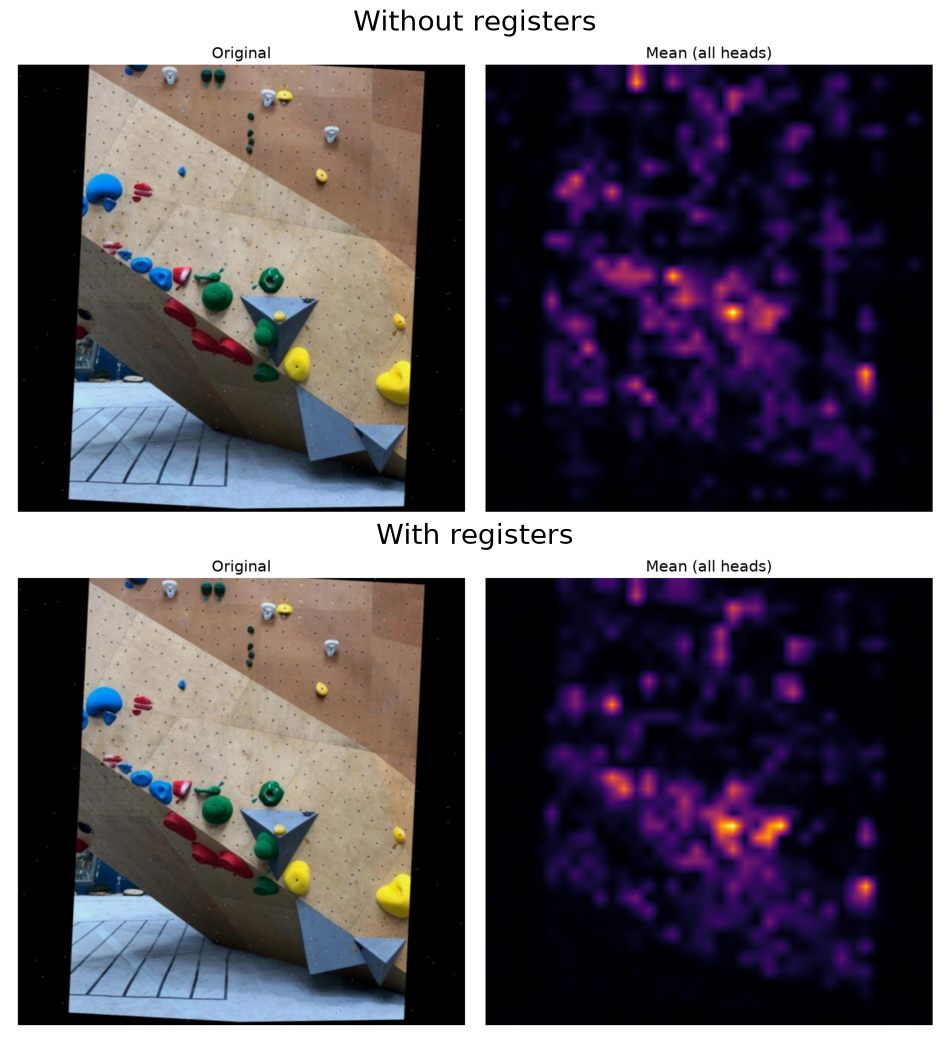

In [25]:
import matplotlib.pyplot as plt
from PIL import Image

img1 = Image.open("results/attention_map_without_registers.png")
img2 = Image.open("results/attention_map_with_registers.png")

fig, axes = plt.subplots(2, 1, figsize=(12, 20))

axes[0].imshow(img1)
axes[0].axis("off")
axes[0].set_title("Without registers", fontsize=20)

axes[1].imshow(img2)
axes[1].axis("off")
axes[1].set_title("With registers", fontsize=20)

plt.subplots_adjust(hspace=-0.5)
plt.show()

### Observations?
- Clearly the one without registers seems wayyyyy more noisy than the one without. A lot of the wall's shadows are messing and playing tricks with the models ability to percieve and distinguish holds from wall.
- Though this could absolutely be a one off case. Need to peruse the actual paper to see what the claims are, and what they suppose their implementation improves.
- There could also be training discrepancy, since when tests are conducted by the labs, they train them together, identically and then benchmark. The two models I've used here have been trained at two different points in time and might have had slightly varying training data, which could also be the factor causing the slight discrepancy.

In [ ]:
'''
Register tokens are a DINOv2-specific addition from a 2023 paper (my previous misconception) - Register tokens were included as a part of a different paper ViT need register tokens(https://arxiv.org/abs/2309.16588).
The original DinoV2 did not include them, they released a new set of models (like the dinov2_reg4 version I'm currently using) which included the register tokens
The problem they solve: in vanilla ViTs, certain patch tokens in "uninformative" regions (smooth backgrounds, uniform areas) get hijacked by the model to store global information.
You can see it as artifact patches with weirdly high attention that don't correspond to anything visual. This pollutes both the patch features and the attention maps.
Register tokens are 4 extra learnable tokens (also 384-dim) inserted between CLS and the patches. They act as "scratchpad"
The model offloads that global bookkeeping onto them instead of corrupting patch tokens. They have no spatial meaning, you discard them for visualisation.

Comment from the paper: 'Interestingly, all models but DINO exhibit peaky outlier values in the attention maps. 
'''

'\nRegister tokens are a DINOv2-specific addition from a 2023 paper. The problem they solve: in vanilla ViTs, certain patch tokens in "uninformative" regions (smooth backgrounds, uniform areas) get hijacked by the model to store global information — you can see it as artifact patches with weirdly high attention that don\'t correspond to anything visual. This pollutes both the patch features and the attention maps.\nRegister tokens are 4 extra learnable tokens (also 384-dim) inserted between CLS and the patches. They act as "scratchpad" — the model offloads that global bookkeeping onto them instead of corrupting patch tokens. They have no spatial meaning, you discard them for visualisation.\n'

## Literature Review: Vision Transformers Need Registers:
- Surprisingly, the outputs of the subsequent DINOv2 models have been shown to hold good local information but exhibit undesirable artifacts in attention maps. 
- In this section, we propose to study why and when these artifacts appear. While this work focuses on alleviating artefacts in all vision transformers, we focus our analysis on DINOv2.
- An 'artifact' in the definition of the paper, is a high attention region with little to no relevant information. "Artifacts are high-norm outlier tokens"


- 'Norm' of a vector is essentially its magnitude. 'High-norm' vector outliers are vectors that have a very high magnitude for no apparent reason (no useful feature in the image - just background or something) - **L2 norm** is sqrt(sum of squares of vector entities)